In [2]:
# 라이브러리 불러오기
import seaborn as sns

# titanic 데이터셋 가져오기
df = sns.load_dataset('titanic')

# age 열의 첫 10개 데이터 출력 (5 행에 NaN 값이 있는것을 확인 - 결측치 확인)
df['age'].head(10)

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5     NaN
6    54.0
7     2.0
8    27.0
9    14.0
Name: age, dtype: float64

(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

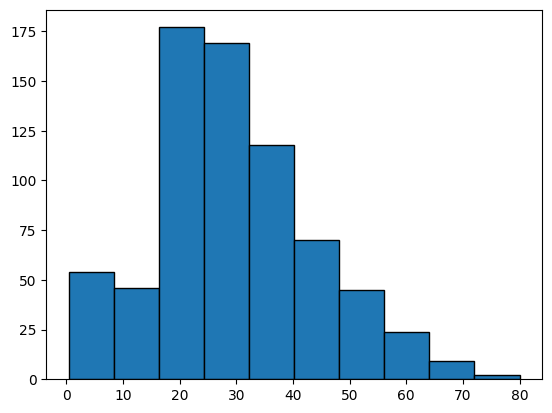

In [7]:
# 나이에 대한 hist
import matplotlib.pyplot as plt
plt.hist(df['age'], bins=10, edgecolor='black')

In [ ]:
# 데이터의 분포가 고르면, 평균을 사용 아닌경우에는 다른 계산값으로 대체한다.
# 위그래프, 위데이터는 분포가 불균형하기 때문에 평균갑이아닌 다른 계산값으로 대체 해야한다는 판단이 선다.

In [ ]:
# age 열의 NaN값을 다른 나이 데이터의 평균으로 변경하기
mean_age = df['age'].mean(axis=0)   # age 열의 평균 계산 (NaN 값 제외)
# median(), mean(), max(), mode(), max()
df['age'] = df['age'].fillna(mean_age)

# age 열의 첫 10개 데이터 출력 (5 행에 NaN 값이 평균으로 대체)
df['age'].head(10)

0    22.000000
1    38.000000
2    26.000000
3    35.000000
4    35.000000
5    29.699118
6    54.000000
7     2.000000
8    27.000000
9    14.000000
Name: age, dtype: float64

In [12]:
df = sns.load_dataset('titanic')
df[df['age'].isnull()] # df 중에서 'age'열에 값이 누락된 행을 조회한다.

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
17,1,2,male,NaN,0,0,13.0000,S,Second,man,True,NaN,Southampton,yes,True
19,1,3,female,NaN,0,0,7.2250,C,Third,woman,False,NaN,Cherbourg,yes,True
26,0,3,male,NaN,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True
28,1,3,female,NaN,0,0,7.8792,Q,Third,woman,False,NaN,Queenstown,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,0,3,male,NaN,0,0,7.2292,C,Third,man,True,NaN,Cherbourg,no,True
863,0,3,female,NaN,8,2,69.5500,S,Third,woman,False,NaN,Southampton,no,False
868,0,3,male,NaN,0,0,9.5000,S,Third,man,True,NaN,Southampton,no,True
878,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# 결측치가 있는 데이터와 동일한 조건을 가진 다른 이들의 평균값이나 중간값을 계산하여 넣는다.
# 객실별, 성별에 따른 평균값으로 해당 결측치를 대처
df.groupby(['pclass','sex'])['age'].mean()
# 결측치 하나하나씩 넣기에는 결측치가 많을때도 있으니 번거로움 ^
df['age'] = df.groupby(['pclass','sex'])['age'].transform('mean')
# transform('mean')은 그룹별 평균값을 원래 데이터프레임 인덱스에 맞춰서 반환
# 즉, 각 사람의 나이 결측치가 같은 그룹 평균으로 채워짐.
# 장점: 결측치가 많아도 자동으로 각 행에 맞게 처리 가능.
# 하지만 그러면 빈값만 채우는게 아니라 모든값을 다 변경되는 것으로
df['age'] = df['age'].fillna(df.groupby(['pclass','sex'])['age'].transform('mean'))
# fillna로 빈값들에만 적용한다.
# https://chatgpt.com/share/68dc7d5f-9d50-8012-9e84-254ad7ee594d

<Axes: >

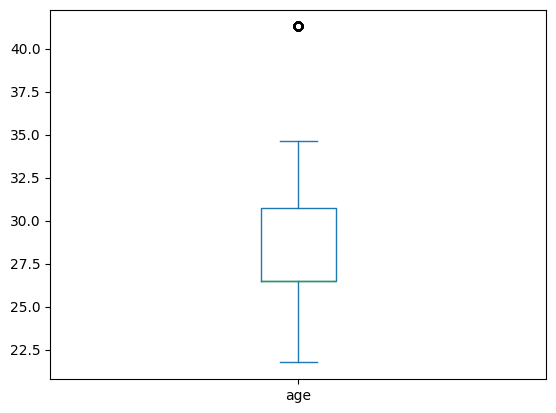

In [18]:
# 평균 VS 중위수 ... 어떤 기준으로 선택할지에 대하여
# 평균
#     이상치의 비중이 낮을 때
# 중위수
#     이상치의 비중이 높을 때

# 결측치가 많을 때 ( 50% 이상 )
# 머신러닝/딥러닝 기반의 보간 고려를 한다.

# 이런 데이터를 다루는 인공지능 학습중에, 결측치가 많아도 버리지 않는 경우가 있는데
# 그 이유는 그 버리는 데이터 내부에서도 패턴이 조금이라도 0.000000001%라도 올려주는 경우 가있기 때문이다.
df['age'].plot(kind='box')

<Axes: >

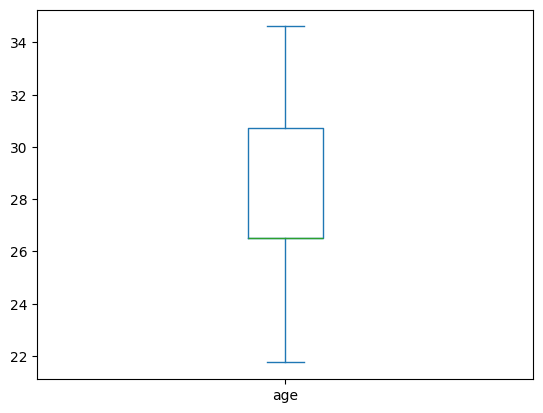

In [ ]:
q1 = df['age'].quantile(0.25)
q3 = df['age'].quantile(0.75)
iqr = q3 - q1
lower = q1 - iqr*1.5 # 이상치 낮은 값의 경우
upper = q3 + iqr*1.5 # 이상치 높은 값의 경우
# 이상치는 Q1보다 너무 작은 값, Q3보다 너무 큰 값으로 정의합니다.
# 여기서 IQR을 기준으로 1.5배 정도를 곱해서 아래/위 경계를 만드는 경우가 많다.
# 1.5배 말고 다른 값으로 한다면 어떤 경향이 나타나는 지에 대해서 ^
outlier_mask = (df['age'] >= lower) & (df['age'] <= upper)
df[outlier_mask]['age'].plot(kind='box')

In [ ]:
# ^
# 델타 = 상대적 평균 - 중앙값의 차이
# rel_diff = abs(mean-median) / abs(median) + 1e-8
# 평균이 중앙값에 얼마나 떨어져 있는지를 상대적으로 본 값
# 값이 크면 분포가 치우쳐져 있거나, 또는 outlier(이상치) 평균을 끌어당긴다.

# 쌔타 : 이상치 비율 ( IQR 기준 )
# IQR = Q3 - Q1 이상치 = (Q1-1.5*IQR ~ Q3+1.5*IQR)
# 관측치 중 IQR기준으로 이상치에 해당하는 값이 차지하는 비율 크면 평균이 불안정
# outlier_frac 이상치 비율    이상치 개수 / 데이터 개수
# outlier_frac = ((df['age']<lower) | (df['age']>upper)).sum()

# if rel_diff < 델타 and outlier_frac < 0 :
#    mean
# else
#    median

# 델타와 세타에 해당하는 값은 
# 보수적(이상치에 민감) 델타 0.05(5%) 세타 0.01(1%)
# 보통(추천) 0.08~0.10    0.02~0.03
# 관대(어느정도 편차는 허용) 0.15 0.05

# 너무 데이터를 정제해서 인공지능을 학습하게 하면, 실제로 사용할때 실제 데이터의 자연스럽게 접근하기가 어려움? ^

In [20]:
print(1e2)
print(1e-2)

100.0
0.01


In [ ]:
import seaborn as sns
titanic = sns.load_dataset('titanic')
titanic = titanic.dropna(subset=['age']) # age 에서만 dropna를 실행
titanic = titanic.dropna()
mean = titanic['age'].mean()
median = titanic['age'].median()
# 상대 차이
rel_diff = abs(mean-median) / abs(median) + 1e-8
# 이상치 비율 계싼 이상치개수 / 전체 개수
# q1 - 1.5*iqr ~ q3+1.t*iqr
q1 = df['age'].quantile(0.25)
q3 = df['age'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr
outlier_frac = ((titanic['age']<lower)|(titanic['age']>upper)).mean() 
delta, setha = 0.08,0.02
if rel_diff < delta and outlier_frac < setha:
    print('mean')
else:
    print('median')

SyntaxError: invalid syntax (84694887.py, line 3)